In [1]:
# Unit test for CAS_preprocess_02_pixel_to_nm.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from PIL import Image
from pathlib import Path
# from config import load_config
import argparse
from datetime import datetime as dt
import h5py
import sys
import ast

code_dir = Path('/code/')
sys.path.append(str(code_dir))

import CAS_preprocess_02_pixel_to_nm as pixel_to_nm
%matplotlib inline

In [2]:
# # Physical constants
# SELLMEIER_COEFFS = (1.73759695, 0.313747356, 1.89878101)
# SELLMEIER_TERMS = (0.013188707, 0.0623068142, 155.23629)
# THETA_I = 60.8  # angle of incidence (degrees)
# ALPHA = 60      # prism apex angle (degrees)

In [3]:
parser = argparse.ArgumentParser(
        description="Calibrate prism dispersion and generate wavelength-to-pixel LUT"
)
parser.add_argument(
    "--results_dir",
    type=str,
    default="/results/",
    help="Directory containing the calibration image and calibration.txt file",
)

args = parser.parse_args(args=[]) # Have to add args=[] to simulate no command-line args
results_dir = Path(args.results_dir)

print(args)
print(results_dir)

Namespace(results_dir='/results/')
/results


In [4]:
calib_image = results_dir / 'CalibrationImage.tiff'
calib_file = results_dir / 'calibration.txt'

print(calib_image)
print(calib_file)

/results/CalibrationImage.tiff
/results/calibration.txt


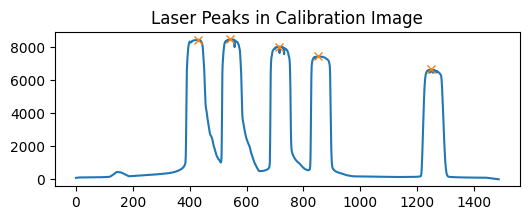

[ 430  543  715  853 1250]


In [5]:
lasers = np.array([0.561, 0.514, 0.473, 0.448, 0.405])
laser_pix = pixel_to_nm.find_laser_pixels(calib_image)

print(laser_pix)

In [6]:
popt, theta_D = pixel_to_nm.fit_wavelength_to_pixels(lasers, laser_pix)
print(f"Fit parameters: a={popt[0]:.4f}, b={popt[1]:.4f}")

Fit parameters: a=89.6624, b=-5598.7059


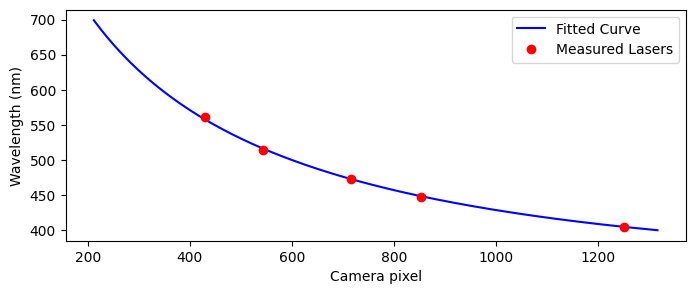

In [7]:
wavelength = np.arange(0.4, 0.7, 0.001)
pixel_value = pixel_to_nm.linear_wave(pixel_to_nm.deviation_angle(wavelength), *popt)

pixel_to_nm.plot_calibration_results(lasers, laser_pix, wavelength, pixel_value)



In [10]:
lut, pixel_value_wave, theta_D_wave = pixel_to_nm.generate_lut(popt, calib_file)
print(lut.head())
print(lut)


   Camera_pixel  Wavelength_nm
0          1664            400
1          1650            401
2          1636            402
3          1622            403
4          1609            404
     Camera_pixel  Wavelength_nm
0            1664            400
1            1650            401
2            1636            402
3            1622            403
4            1609            404
..            ...            ...
295           564            695
296           563            696
297           562            697
298           561            698
299           560            699

[300 rows x 2 columns]


In [11]:
# Version 2
hdf5_file = results_dir / 'pixel_to_nm_V2.hdf5'
store = pd.HDFStore(hdf5_file, mode='a')
for col in lut.columns:
    lut[col].to_hdf(store, key=col, mode='a')
store.close()
    
with h5py.File(hdf5_file, 'r') as f:
    print("HDF5 keys:", list(f.keys()))

HDF5 keys: ['Camera_pixel', 'Wavelength_nm']


In [16]:
def read_hdf_columns_via_pandas(hdf_path):
    """Read all datasets written by pd.DataFrame.to_hdf."""
    store = pd.HDFStore(hdf_path, mode='r')
    data = {}
    for key in store.keys():  # keys() returns ['/Camera_pixel', '/Wavelength_nm']
        clean_key = key.strip('/')  # remove leading slash
        data[clean_key] = store[clean_key].values
    store.close()
    return data



In [18]:
file_v1 = results_dir/'pixel_to_nm.hdf5'
file_v2 = hdf5_file

data_v1 = read_hdf_columns_via_pandas(file_v1)
data_v2 = read_hdf_columns_via_pandas(file_v2)

In [19]:
# Compare keys
assert set(data_v1.keys()) == set(data_v2.keys()), "Keys differ!"

In [20]:
# Compare values
for key in data_v1.keys():
    assert np.array_equal(data_v1[key], data_v2[key]), f"Mismatch in dataset: {key}"

print("✅ Unit test passed: Version 1 and Version 2 outputs are identical.")

✅ Unit test passed: Version 1 and Version 2 outputs are identical.
